# 🧠 Day 2 — DBSCAN & Hierarchical Clustering

**BinX Tech • AI & Machine Learning Internship • Week 5**

## 🎯 Learning Objectives
- Explain K-Means limitations and when another method may be preferable.
- Run DBSCAN and interpret clusters and noise points.
- Build and read a hierarchical clustering dendrogram.
- Compare K-Means, DBSCAN, and hierarchical clustering on the same data.
- Choose a clustering method based on the observed structure.

## 📌 Dataset
This notebook continues with the **same Mall Customers dataset used in Day 1**, as required by the Hands-On Lab.

Clustering uses the same three numeric features:
- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

`CustomerID` is an identifier and is excluded. `Gender` is categorical and is excluded because the workflow uses numeric features only.

All distance-based methods use standardized features.

## 🔍 1. Why K-Means Isn't Always Enough

K-Means has several limitations:
- `k` must be chosen before fitting.
- It works best when clusters are reasonably round and similarly sized.
- It assigns every observation to a cluster, even clear outliers.

Two alternatives address these weaknesses:
- **DBSCAN:** density-based clustering with explicit noise detection.
- **Hierarchical clustering:** a hierarchy of nested clusters represented by a dendrogram.

The goal today is to compare these methods on the **same dataset**, not to assume that one method is always best.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
N_INIT = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 📥 2. Load and Check the Day 1 Dataset

The Day 2 lab explicitly asks us to run DBSCAN on the Day 1 dataset, so I reuse the same CSV.

In [2]:
df = pd.read_csv("Mall_Customers.csv")

numeric_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

print(f"Dataset shape: {df.shape}")
display(df.head())

assert df[numeric_features].isna().sum().sum() == 0
assert all(pd.api.types.is_numeric_dtype(df[c]) for c in numeric_features)
assert df.duplicated().sum() == 0
assert df["CustomerID"].is_unique

print("✓ No missing values in clustering features.")
print("✓ All clustering features are numeric.")
print("✓ No duplicate rows.")
print("✓ CustomerID is unique.")

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


✓ No missing values in clustering features.
✓ All clustering features are numeric.
✓ No duplicate rows.
✓ CustomerID is unique.


## 📏 3. Standardize the Clustering Features

DBSCAN and hierarchical clustering are distance-based in this workflow. I therefore keep the same scaling discipline used in Day 1.

In [3]:
X = df[numeric_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)

print("Scaled feature means:")
display(X_scaled_df.mean().round(6).to_frame("mean"))

print("Scaled feature standard deviations:")
display(X_scaled_df.std(ddof=0).round(6).to_frame("std"))

Scaled feature means:


,mean
Age,-0.000
Annual Income (k$),-0.000
Spending Score (1-100),-0.000


Scaled feature standard deviations:


,std
Age,1.000
Annual Income (k$),1.000
Spending Score (1-100),1.000


## 🔐 4. Methodological / Leakage Check

There is no target variable in this unsupervised task, so supervised train/test leakage is not the relevant concern.

The important feature-selection checks are:
- `CustomerID` is excluded because it is only an identifier.
- `Gender` is excluded because the workflow specifies numeric clustering features.
- All three methods use the same standardized feature representation.

# 🖥️ Hands-On Lab: Comparing Clustering Methods

This is a separate required workflow following the four lab steps:

1. Run DBSCAN and report its clusters and noise points.
2. Build a hierarchical dendrogram and choose a cut height, reporting the resulting cluster count.
3. Compare K-Means, DBSCAN, and hierarchical clustering on the same data.
4. State which method best fits the observed dataset structure and explain why.

## 🧩 Step 1 — DBSCAN

DBSCAN uses two key parameters:
- `eps`: neighborhood radius.
- `min_samples`: minimum number of observations needed for a dense region.

The training material's example uses `eps=0.5` and `min_samples=5`, so I start with those supplied values.

DBSCAN uses label `-1` for noise / outlier observations.

In [4]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

cluster_labels = sorted(label for label in np.unique(db_labels) if label != -1)
noise_count = int(np.sum(db_labels == -1))
cluster_count = len(cluster_labels)

print(f"DBSCAN clusters found: {cluster_count}")
print(f"Noise points found: {noise_count}")

display(
    pd.Series(db_labels, name="count")
    .value_counts()
    .sort_index()
    .to_frame()
)

DBSCAN clusters found: 6
Noise points found: 60


,count
count,
-1,60
0,17
1,5
2,51
3,28
4,32
5,7


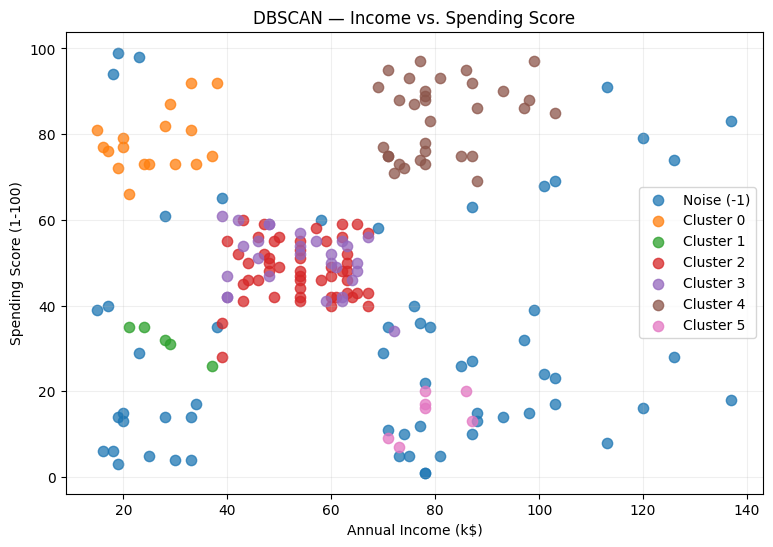

In [5]:
dbscan_result = df.copy()
dbscan_result["DBSCAN_Cluster"] = db_labels

plt.figure(figsize=(9, 6))
for label in sorted(np.unique(db_labels)):
    subset = dbscan_result[dbscan_result["DBSCAN_Cluster"] == label]
    name = "Noise (-1)" if label == -1 else f"Cluster {label}"
    plt.scatter(
        subset["Annual Income (k$)"],
        subset["Spending Score (1-100)"],
        label=name,
        alpha=0.75,
        s=55
    )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN — Income vs. Spending Score")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### 🔎 DBSCAN Interpretation

Unlike K-Means, DBSCAN does not require the number of clusters in advance. It identifies dense regions using `eps` and `min_samples`.

The `-1` label is important because those observations are not forced into a regular cluster. They are treated as noise under the selected density parameters.

The result should be interpreted together with the visualization because DBSCAN is sensitive to `eps`.

## 🌳 Step 2 — Hierarchical Clustering & Dendrogram

Hierarchical clustering starts with each observation as its own cluster and repeatedly merges the closest groups.

The resulting **dendrogram** shows the hierarchy. A horizontal cut can then be selected to obtain a chosen number of groups.

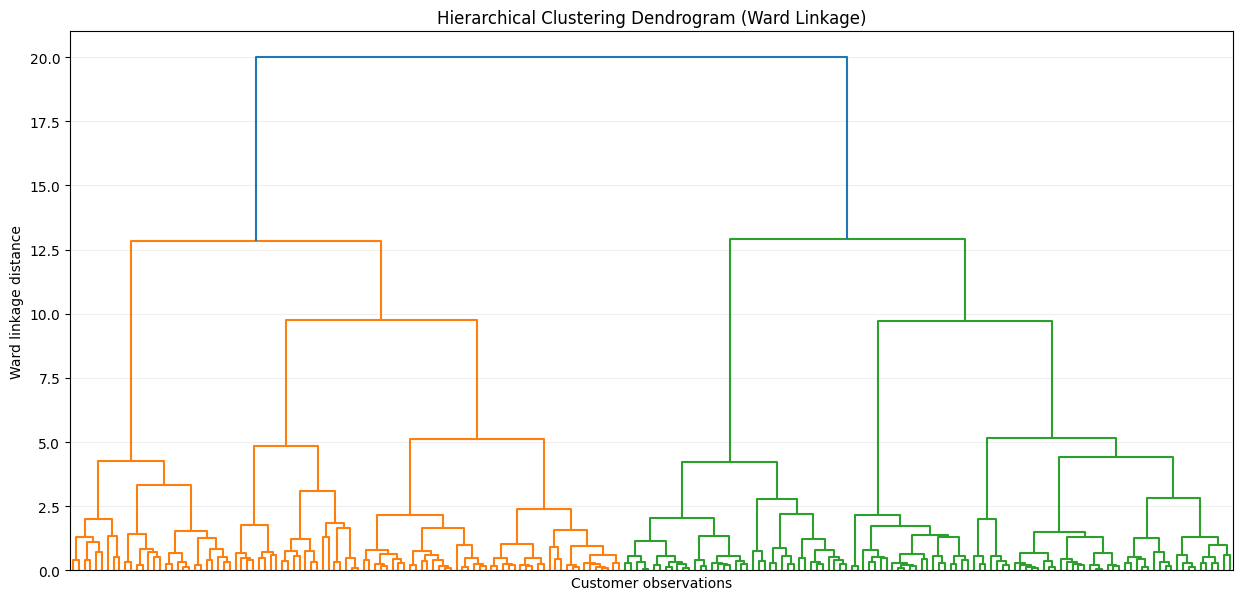

In [6]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(15, 7))
dendrogram(Z, no_labels=True)
plt.xlabel("Customer observations")
plt.ylabel("Ward linkage distance")
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.grid(axis="y", alpha=0.2)
plt.show()

### ✂️ Choosing a Dendrogram Cut

I will use a cut that produces **five clusters**, matching the final K-Means solution selected in Day 1. This makes the comparison easier because the hierarchical result is not being given a different target number of groups.

The cut height is calculated from the actual Ward linkage distances.

In [7]:
# For 200 observations, Z[-5] is the merge after which 5 clusters remain.
five_cluster_level = Z[-5, 2]
four_cluster_level = Z[-4, 2]
cut_height = (five_cluster_level + four_cluster_level) / 2

hier_labels = fcluster(Z, t=cut_height, criterion="distance")
hier_cluster_count = len(np.unique(hier_labels))

print(f"Distance before the 5→4 merge: {five_cluster_level:.4f}")
print(f"Distance at the 5→4 merge: {four_cluster_level:.4f}")
print(f"Chosen cut height: {cut_height:.4f}")
print(f"Resulting hierarchical cluster count: {hier_cluster_count}")

assert hier_cluster_count == 5

Distance before the 5→4 merge: 9.7190
Distance at the 5→4 merge: 9.7392
Chosen cut height: 9.7291
Resulting hierarchical cluster count: 5


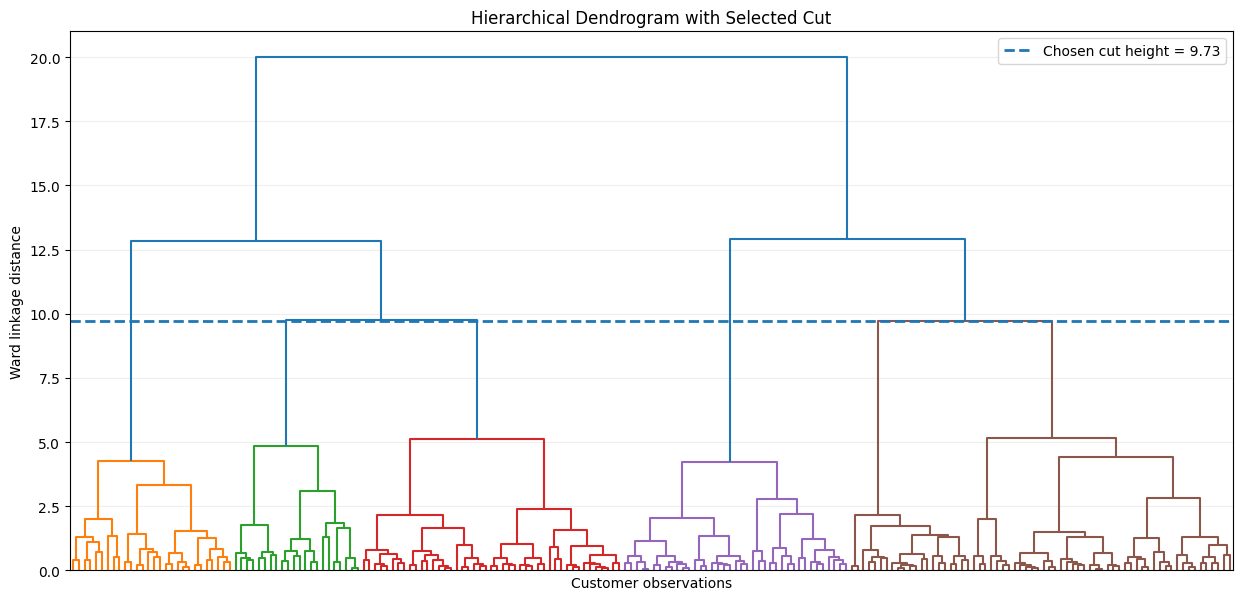

In [8]:
plt.figure(figsize=(15, 7))
dendrogram(Z, no_labels=True, color_threshold=cut_height)
plt.axhline(
    cut_height,
    linestyle="--",
    linewidth=2,
    label=f"Chosen cut height = {cut_height:.2f}"
)
plt.xlabel("Customer observations")
plt.ylabel("Ward linkage distance")
plt.title("Hierarchical Dendrogram with Selected Cut")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()

## 📊 Step 3 — Compare K-Means, DBSCAN, and Hierarchical Clustering

For a fair comparison:
- **K-Means:** `k=5`, selected in Day 1.
- **DBSCAN:** `eps=0.5`, `min_samples=5`, as supplied in the lesson example.
- **Hierarchical:** Ward linkage with the selected five-cluster cut.

All three methods use the same standardized features.

In [9]:
kmeans = KMeans(
    n_clusters=5,
    random_state=RANDOM_STATE,
    n_init=N_INIT
)
kmeans_labels = kmeans.fit_predict(X_scaled)

comparison = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN", "Hierarchical (Ward)"],
    "Clusters": [
        len(np.unique(kmeans_labels)),
        cluster_count,
        hier_cluster_count
    ],
    "Noise Points": [0, noise_count, 0]
})

display(comparison)

,Method,Clusters,Noise Points
0,K-Means,5,0
1,DBSCAN,6,60
2,Hierarchical (Ward),5,0


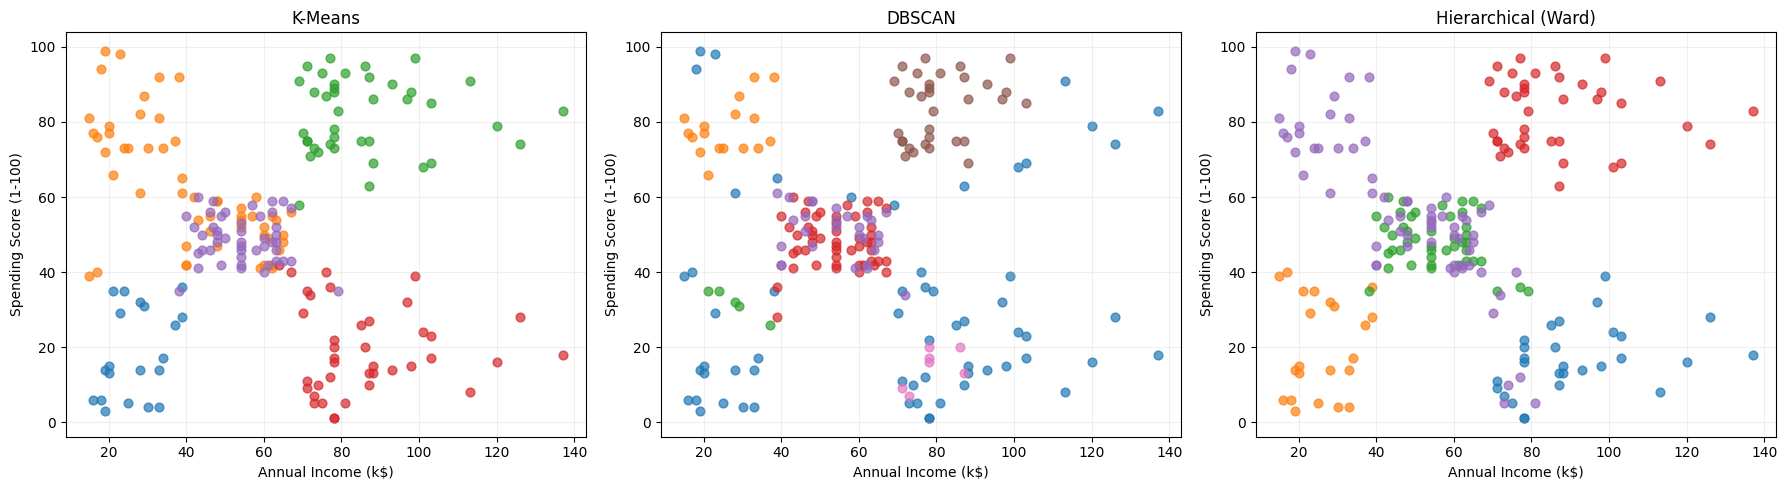

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    ("K-Means", kmeans_labels),
    ("DBSCAN", db_labels),
    ("Hierarchical (Ward)", hier_labels)
]

for ax, (name, labels) in zip(axes, methods):
    for label in sorted(np.unique(labels)):
        idx = np.where(labels == label)[0]
        subset = df.iloc[idx]
        display_label = "Noise (-1)" if label == -1 else f"Cluster {label}"
        ax.scatter(
            subset["Annual Income (k$)"],
            subset["Spending Score (1-100)"],
            label=display_label,
            alpha=0.70,
            s=40
        )

    ax.set_title(name)
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 🧠 Comparison Interpretation

**K-Means** gives a clean five-group partition, but it requires `k` beforehand and assigns every customer to a cluster.

**DBSCAN** does not require `k` and can explicitly label sparse observations as noise. Its result, however, depends strongly on `eps` and `min_samples`.

**Hierarchical clustering** provides a dendrogram and exposes nested relationships. It is especially useful when understanding the hierarchy itself matters.

Different outputs do not automatically mean that one algorithm is wrong. Each method defines a cluster differently.

## 🔬 Additional Diagnostic — Silhouette Score

The lab does not require a silhouette comparison today, but I include it as an additional internal diagnostic.

For DBSCAN, noise points (`-1`) are excluded from the silhouette calculation because they represent noise rather than a regular cluster.

In [11]:
def safe_silhouette(X_values, labels, ignore_noise=False):
    labels_array = np.asarray(labels)

    if ignore_noise:
        mask = labels_array != -1
        X_values = X_values[mask]
        labels_array = labels_array[mask]

    if len(np.unique(labels_array)) < 2:
        return np.nan

    return silhouette_score(X_values, labels_array)

comparison_metrics = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN (non-noise)", "Hierarchical (Ward)"],
    "Silhouette": [
        safe_silhouette(X_scaled, kmeans_labels),
        safe_silhouette(X_scaled, db_labels, ignore_noise=True),
        safe_silhouette(X_scaled, hier_labels)
    ]
})

display(comparison_metrics.round(4))

,Method,Silhouette
0,K-Means,0.417
1,DBSCAN (non-noise),0.482
2,Hierarchical (Ward),0.390


## 🏆 Step 4 — Which Method Best Fits This Dataset?

For this particular Mall Customers dataset, **K-Means is the most practical primary method**.

The customer data forms relatively compact and interpretable groups in the selected feature space, and Day 1 already provided evidence supporting a five-cluster K-Means solution through the elbow and silhouette workflow.

DBSCAN is more attractive when irregularly shaped groups and meaningful noise are central to the problem. Here, its behavior is sensitive to density parameters and the supplied starting values do not provide the same clean segmentation.

Hierarchical clustering is valuable for exploration because the dendrogram reveals nested structure, but the additional hierarchy is less necessary for this dataset than the simpler K-Means segmentation.

> **Conclusion:** K-Means best fits the observed structure of this dataset, while hierarchical clustering is a useful exploratory complement and DBSCAN would become more attractive if irregular shapes or meaningful outliers were present.

## 🌟 Beyond the Requirement — DBSCAN Sensitivity

DBSCAN's `eps` parameter is sensitive. To demonstrate this without changing the required lab result, I test a small range around the supplied `eps=0.5`, keeping `min_samples=5`.

This illustrates why DBSCAN needs parameter reasoning rather than treating one parameter pair as universally correct.

In [12]:
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7]
sensitivity = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels_eps = model.fit_predict(X_scaled)
    sensitivity.append({
        "eps": eps,
        "clusters": len(set(labels_eps) - {-1}),
        "noise_points": int(np.sum(labels_eps == -1))
    })

sensitivity_df = pd.DataFrame(sensitivity)
display(sensitivity_df)

,eps,clusters,noise_points
0,0.300,10,134
1,0.400,6,98
2,0.500,6,60
3,0.600,2,28
4,0.700,1,14


## 🧪 6. Final Sanity & Reproducibility Checks

The final checks verify that:
- all methods used the same observations and standardized features;
- K-Means and hierarchical clustering have five clusters;
- DBSCAN's noise label is handled separately;
- the selected dendrogram cut really produces five clusters;
- the outputs are valid and reproducible.

In [13]:
assert X_scaled.shape == (len(df), len(numeric_features))
assert len(kmeans_labels) == len(df)
assert len(db_labels) == len(df)
assert len(hier_labels) == len(df)
assert len(np.unique(kmeans_labels)) == 5
assert hier_cluster_count == 5
assert np.isfinite(cut_height)

print("✓ Same observations used by all methods.")
print("✓ Same standardized feature representation used.")
print("✓ K-Means produced 5 clusters.")
print("✓ Hierarchical clustering produced 5 clusters.")
print(f"✓ DBSCAN identified {noise_count} noise points.")
print("✓ Reproducibility settings are fixed.")

✓ Same observations used by all methods.
✓ Same standardized feature representation used.
✓ K-Means produced 5 clusters.
✓ Hierarchical clustering produced 5 clusters.
✓ DBSCAN identified 60 noise points.
✓ Reproducibility settings are fixed.


## 🎯 7. Objective → Evidence Mapping

| Objective | Evidence |
|---|---|
| Explain K-Means limitations | Section 1 explains the need for `k`, shape assumptions, and forced assignments. |
| Run DBSCAN | DBSCAN is fitted on the Day 1 dataset and clusters/noise are reported. |
| Interpret DBSCAN noise | Label `-1` is explicitly separated and visualized. |
| Build/read a dendrogram | Ward linkage dendrogram is generated and a data-derived cut height is selected. |
| Compare methods | K-Means, DBSCAN, and hierarchical results are tabulated and visualized on the same data. |
| Choose a method | Final Markdown connects the observed structure to each method's strengths and limitations. |
| Reproducibility | Fixed random state and explicit method parameters are used.

## 💭 8. Reflection

Today showed me why there is no single clustering algorithm that is automatically correct for every dataset.

K-Means was straightforward and produced an interpretable five-segment solution, but it required the number of clusters to be chosen in advance and has no built-in concept of noise. DBSCAN addressed those weaknesses by allowing observations to be labeled as noise and discovering dense groups automatically, but its result depended strongly on the density parameters.

Hierarchical clustering gave a different perspective because the dendrogram showed how groups form at different levels of similarity.

For this Mall Customers dataset, I would use **K-Means as the primary segmentation method**, while keeping hierarchical clustering as a useful exploratory tool. I would prefer DBSCAN if the data showed clear irregular shapes or meaningful outliers.

## 🏁 9. Final Takeaways

- **K-Means:** practical for compact customer segments, but requires `k` and assigns every point.
- **DBSCAN:** discovers dense groups without preselecting `k` and can identify noise, but is sensitive to `eps` and `min_samples`.
- **Hierarchical clustering:** provides a dendrogram and nested view of the data.
- Different algorithms can legitimately produce different clusterings because they define similarity differently.
- For this dataset, **K-Means is the most suitable primary method** based on the observed structure and the evidence collected across Day 1 and Day 2.

### 🏆 Day 2 Conclusion
The key lesson is not simply how to run three algorithms. It is how to **choose a clustering method based on data shape, noise, and the kind of structure I need to discover**.